# Predicting Earnings — Multivariable Regression 💵

Using the **National Longitudinal Survey of Youth 1997–2011 (NLSY97)** we build a regression model to predict people's hourly earnings from characteristics like years of schooling, work experience and ability, then analyse and improve it.

**Key variables:** `S` = years of schooling, `EXP` = years of work experience, `EARNINGS` = hourly earnings (\$, 2011).

> **How to read the results.** This is observational survey data, so the model shows **associations, not causes**. A coefficient tells us how earnings tend to differ with a feature *holding the others constant* — it does not prove that changing the feature would cause that change, and factors not in the data could be driving the relationships.

### Import & Setup

In [1]:
%pip install --upgrade plotly -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import plotly.io as pio
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

%matplotlib inline
pio.renderers.default = "png"   # embed Plotly charts as images (show on GitHub too)
sns.set_style("whitegrid")
pd.options.display.float_format = "{:,.2f}".format

### Load the Data

In [3]:
df_data = pd.read_csv('NLSY97_subset.csv')

# Preliminary Data Exploration 🔎

In [4]:
df_data.shape

(2000, 96)

In [5]:
# Missing values (columns with any NaN)
df_data.isna().sum()[df_data.isna().sum() > 0]

AGEMBTH       44
HHINC97      370
POVRAT97     373
PRMONM       879
PRMONF      1073
PRMSTYUN     533
PRMSTYPE     533
PRMSTYAN     533
PRMSTYAE     533
PRFSTYUN     790
PRFSTYPE     790
PRFSTYAN     790
PRFSTYAE     790
SFR          399
SMR           82
JOBS          47
dtype: int64

In [6]:
# Duplicate rows
print('duplicate rows:', df_data.duplicated().sum())

duplicate rows: 513


## Data Cleaning — remove duplicates

In [7]:
df = df_data.drop_duplicates()
print(f"{len(df_data)} -> {len(df)} rows after removing {df_data.duplicated().sum()} duplicates")

2000 -> 1487 rows after removing 513 duplicates


## Descriptive Statistics

In [8]:
df[['EARNINGS', 'S', 'EXP']].describe()

,EARNINGS,S,EXP
count,"1,487.00","1,487.00","1,487.00"
mean,18.81,14.56,6.70
std,12.00,2.77,2.86
min,2.00,6.00,0.00
25%,11.41,12.00,4.65
50%,15.75,15.00,6.63
75%,22.60,16.00,8.71
max,132.89,20.00,14.73


## Visualise the Features

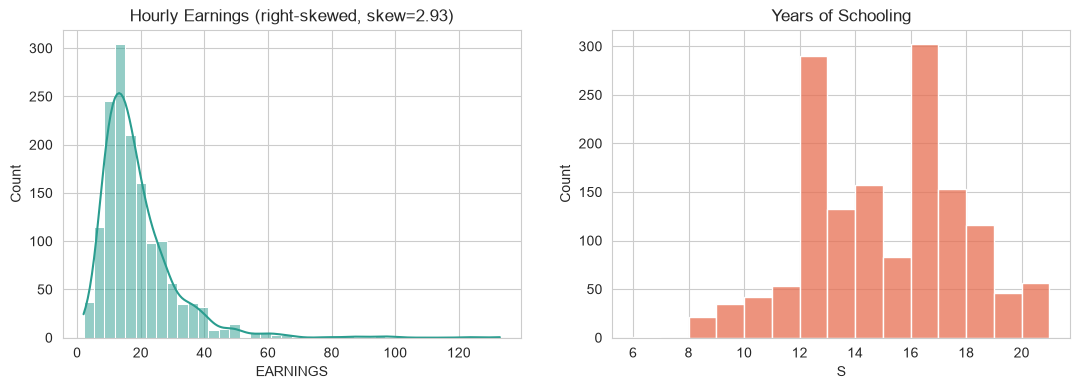

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df['EARNINGS'], bins=40, kde=True, color='#2a9d8f', ax=ax[0])
ax[0].set_title(f'Hourly Earnings (right-skewed, skew={df.EARNINGS.skew():.2f})')
sns.histplot(df['S'], bins=range(6, 22), color='#e76f51', ax=ax[1])
ax[1].set_title('Years of Schooling')
plt.show()

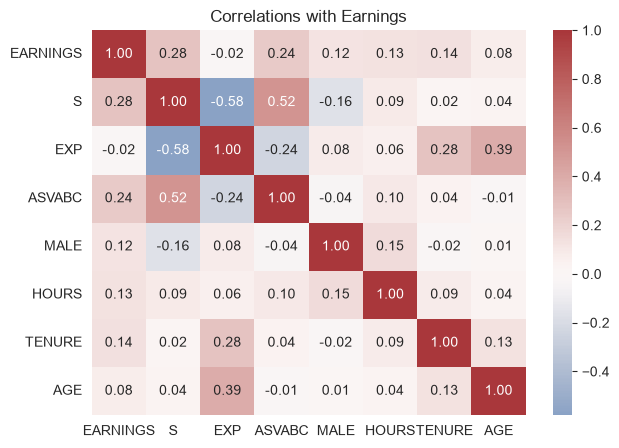

In [10]:
# How each feature correlates with earnings
key = ['EARNINGS', 'S', 'EXP', 'ASVABC', 'MALE', 'HOURS', 'TENURE', 'AGE']
plt.figure(figsize=(7, 5))
sns.heatmap(df[key].corr(), annot=True, fmt='.2f', cmap='vlag', center=0)
plt.title('Correlations with Earnings')
plt.show()

> Schooling (`S`) has the strongest positive correlation with earnings, followed by ability (`ASVABC`). Raw experience barely correlates on its own — but it matters once schooling is held constant (below).

# Split Training & Test Datasets

Hold out 20% as out-of-sample test data.

In [11]:
target = df['EARNINGS']
features_simple = df[['S']]
X_train, X_test, y_train, y_test = train_test_split(
    features_simple, target, test_size=0.2, random_state=10)
print('training rows:', len(X_train), '| test rows:', len(X_test))

training rows: 1189 | test rows: 298


# Simple Linear Regression — Earnings ~ Schooling

In [12]:
reg = LinearRegression().fit(X_train, y_train)
print(f"R-squared (train): {reg.score(X_train, y_train):.3f}")

R-squared (train): 0.081


### Evaluate the Coefficients

In [13]:
print(f"Intercept: {reg.intercept_:.2f}")
print(f"Coefficient on S: {reg.coef_[0]:.2f}")
print(f"\n=> Each extra year of schooling is associated with about "
      f"${reg.coef_[0]:.2f} more per hour.")

Intercept: 1.03
Coefficient on S: 1.22

=> Each extra year of schooling is associated with about $1.22 more per hour.


### Analyse the Residuals

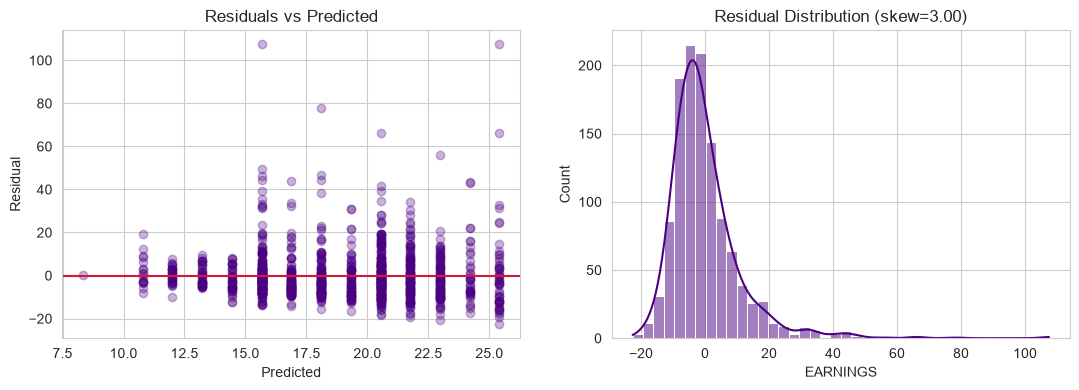

In [14]:
predicted = reg.predict(X_train)
residuals = y_train - predicted
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].scatter(predicted, residuals, alpha=0.3, color='indigo')
ax[0].axhline(0, color='crimson'); ax[0].set_xlabel('Predicted'); ax[0].set_ylabel('Residual')
ax[0].set_title('Residuals vs Predicted')
sns.histplot(residuals, bins=40, kde=True, ax=ax[1], color='indigo')
ax[1].set_title(f'Residual Distribution (skew={residuals.skew():.2f})')
plt.show()

> The residuals are strongly right-skewed and fan out — a sign that a straight line on raw earnings isn't the best fit. We'll fix this later with a log transform.

# Multivariable Regression — Earnings ~ Schooling + Experience

In [15]:
X = df[['S', 'EXP']]
X_train, X_test, y_train, y_test = train_test_split(X, target, test_size=0.2, random_state=10)
reg2 = LinearRegression().fit(X_train, y_train)
print(f"R-squared (train): {reg2.score(X_train, y_train):.3f}")
print(f"R-squared (test):  {reg2.score(X_test, y_test):.3f}")

R-squared (train): 0.117
R-squared (test):  0.087


### Evaluate the Coefficients

In [16]:
pd.DataFrame(reg2.coef_, index=['S', 'EXP'], columns=['Coefficient']).round(2)

,Coefficient
S,1.79
EXP,0.98


> Adding experience raises the fit and gives sensible signs: **~\$1.79/hr per year of schooling** and **~\$0.98/hr per year of experience**.

# Use the Model to Make a Prediction

How much might someone with a **bachelor's degree (16 years of schooling)** and **5 years of experience** expect to earn?

In [17]:
person = pd.DataFrame([[16, 5]], columns=['S', 'EXP'])
print(f"Predicted earnings: ${reg2.predict(person)[0]:.2f} per hour")

Predicted earnings: $19.71 per hour


# Experiment: Improving the Model

Two improvements: **(1) add more predictors** (ability, hours, tenure, sex, ethnicity, age) and **(2) model the log of earnings**, since earnings are highly skewed and grow multiplicatively.

### 1) Add more features

In [18]:
features = ['S', 'EXP', 'MALE', 'ASVABC', 'HOURS', 'TENURE', 'ETHBLACK', 'ETHHISP', 'AGE']
X = df[features]
X_train, X_test, y_train, y_test = train_test_split(X, target, test_size=0.2, random_state=10)
reg3 = LinearRegression().fit(X_train, y_train)
print(f"R-squared (train): {reg3.score(X_train, y_train):.3f}")
print(f"R-squared (test):  {reg3.score(X_test, y_test):.3f}")

R-squared (train): 0.167
R-squared (test):  0.116


### 2) Log-transform the target

`log(earnings)` is far more symmetric, which suits a linear model better.

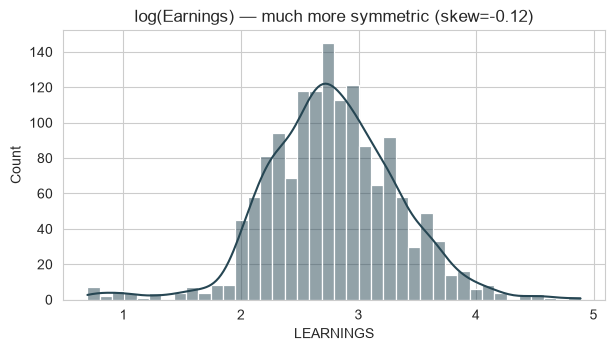

In [19]:
df['LEARNINGS'] = np.log(df['EARNINGS'])
plt.figure(figsize=(7, 3.5))
sns.histplot(df['LEARNINGS'], bins=40, kde=True, color='#264653')
plt.title(f'log(Earnings) — much more symmetric (skew={df.LEARNINGS.skew():.2f})')
plt.show()

In [20]:
log_target = df['LEARNINGS']
X_train, X_test, yl_train, yl_test = train_test_split(X, log_target, test_size=0.2, random_state=10)
reg4 = LinearRegression().fit(X_train, yl_train)
print(f"R-squared (train): {reg4.score(X_train, yl_train):.3f}")
print(f"R-squared (test):  {reg4.score(X_test, yl_test):.3f}")

R-squared (train): 0.235
R-squared (test):  0.192


> The model improves at each step: **R² ≈ 0.08 (schooling only) → 0.12 (+ experience) → 0.17 (+ more features) → 0.24 (log model)**.

### Which features matter? (statsmodels OLS, with p-values)

In [21]:
ols = sm.OLS(log_target, sm.add_constant(X)).fit()
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:              LEARNINGS   R-squared:                       0.228
Model:                            OLS   Adj. R-squared:                  0.224
Method:                 Least Squares   F-statistic:                     48.58
Date:                Wed, 01 Jul 2026   Prob (F-statistic):           3.80e-77
Time:                        15:10:26   Log-Likelihood:                -1043.2
No. Observations:                1487   AIC:                             2106.
Df Residuals:                    1477   BIC:                             2159.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.3349      0.283      4.715      0.0

In [22]:
# Coefficients on log-earnings ~ approximate % change per unit
coef = ols.params.drop('const')
signif = ols.pvalues.drop('const') < 0.05
summary = pd.DataFrame({'coef': coef.round(3),
                        'approx_%_effect': (coef * 100).round(1),
                        'significant (p<0.05)': signif})
summary

,coef,approx_%_effect,significant (p<0.05)
S,0.09,8.80,True
EXP,0.04,4.40,True
MALE,0.18,18.20,True
ASVABC,0.04,4.40,True
HOURS,0.01,0.60,True
TENURE,0.02,2.40,True
ETHBLACK,-0.06,-5.50,False
ETHHISP,0.08,8.30,True
AGE,-0.02,-1.90,False


> **Reading these (with care):** in this sample, holding the other variables constant, each extra year of schooling is associated with **~9% higher** hourly earnings and each ASVAB ability point with a few percent more. The `MALE` coefficient (~+18%) and the ethnicity coefficients describe **associations in the survey data** — differences that remain after adjusting for the included factors — **not causal effects**, and not the whole story (other unmeasured factors matter too).

# Summary

* Earnings rise with **schooling, experience, ability, hours and tenure** — all with the expected signs and statistically significant.
* A single feature explains little (R² ≈ 0.08); adding predictors and modelling **log(earnings)** roughly **triples** the explained variance (R² ≈ 0.24).
* Even so, most of the variation in earnings is **not** explained by these measured factors — a reminder of how much luck, circumstance and unmeasured traits shape what people earn.
* All relationships here are **associations in observational data**, useful for understanding patterns but not for claiming cause and effect.